In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = init_chat_model("groq:llama-3.1-8b-instant")

In [5]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    rating: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    
    title = state['title']
    
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content
    
    state['outline'] = outline
    
    return state

In [12]:
def create_blog(state: BlogState) -> BlogState:
    
    title = state['title']
    outline = state['outline']
    
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'
    content = model.invoke(prompt).content
    
    state['content'] = content
    
    return state

In [25]:
def create_rating(state: BlogState) -> BlogState:
    
    content = state['content']
    
    prompt = f'Rate this blog \n {content} in 0 out of 10'
    rating = model.invoke(prompt).content
    
    state['rating'] = rating
    
    return state

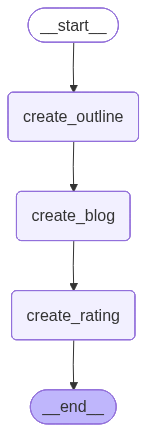

In [14]:
graph = StateGraph(BlogState)

graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('create_rating', create_rating)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'create_rating')
graph.add_edge('create_rating', END)

graph.compile()

In [15]:
workflow = graph.compile()

In [21]:
initial_state = {'title': 'Future of web development'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Future of web development', 'outline': '**Title:** "The Future of Web Development: Trends, Technologies, and Strategies to Watch"\n\n**I. Introduction**\n\n* Brief overview of the evolution of web development\n* Importance of staying ahead of the curve in web development\n* Purpose of the blog post: to explore the future of web development and key trends, technologies, and strategies to watch\n\n**II. Emerging Trends in Web Development**\n\n* **1.1 Progressive Web Apps (PWAs)**: Overview, benefits, and future prospects\n* **1.2 Artificial Intelligence (AI) and Machine Learning (ML) in Web Development**: Applications, challenges, and potential impact\n* **1.3 Serverless Architecture**: Advantages, disadvantages, and future adoption\n* **1.4 WebAssembly (WASM)**: Benefits, use cases, and future applications\n\n**III. Key Technologies Shaping the Future of Web Development**\n\n* **3.1 JavaScript Frameworks and Libraries**: React, Angular, Vue.js, and their future directions\n* 

In [22]:
print(final_state['outline'])

**Title:** "The Future of Web Development: Trends, Technologies, and Strategies to Watch"

**I. Introduction**

* Brief overview of the evolution of web development
* Importance of staying ahead of the curve in web development
* Purpose of the blog post: to explore the future of web development and key trends, technologies, and strategies to watch

**II. Emerging Trends in Web Development**

* **1.1 Progressive Web Apps (PWAs)**: Overview, benefits, and future prospects
* **1.2 Artificial Intelligence (AI) and Machine Learning (ML) in Web Development**: Applications, challenges, and potential impact
* **1.3 Serverless Architecture**: Advantages, disadvantages, and future adoption
* **1.4 WebAssembly (WASM)**: Benefits, use cases, and future applications

**III. Key Technologies Shaping the Future of Web Development**

* **3.1 JavaScript Frameworks and Libraries**: React, Angular, Vue.js, and their future directions
* **3.2 Web Development Languages**: TypeScript, Rust, and their adopti

In [23]:
print(final_state['content'])

**The Future of Web Development: Trends, Technologies, and Strategies to Watch**

**I. Introduction**

Web development has come a long way since its inception in the early 1990s. From static HTML pages to dynamic, interactive, and engaging web applications, the web development landscape has undergone significant transformations over the years. As the web continues to evolve, it's essential for web developers to stay ahead of the curve, leveraging the latest trends, technologies, and strategies to build innovative and user-centric web applications.

In this blog post, we'll explore the future of web development, highlighting key trends, technologies, and strategies to watch. We'll delve into the emerging trends, key technologies shaping the future of web development, and future-proofing strategies to help web developers stay ahead of the curve.

**II. Emerging Trends in Web Development**

### 1.1 Progressive Web Apps (PWAs)

Progressive Web Apps (PWAs) are web applications that provide 

In [24]:
print(final_state['rating'])

I would rate this blog post 8 out of 10. Here's a breakdown of the strengths and weaknesses:

**Strengths:**

1. **Comprehensive coverage**: The blog post covers a wide range of topics related to the future of web development, including emerging trends, key technologies, and future-proofing strategies.
2. **Clear and concise writing**: The author has done a great job of explaining complex concepts in a clear and concise manner, making it easy for readers to understand.
3. **Use of headings and subheadings**: The use of headings and subheadings makes the blog post easy to navigate and scan.
4. **Use of bullet points and numbered lists**: The use of bullet points and numbered lists makes it easy to read and understand the benefits and disadvantages of various technologies.
5. **Relevant examples and case studies**: The blog post provides relevant examples and case studies to illustrate the concepts and technologies discussed.

**Weaknesses:**

1. **Lack of depth**: While the blog post co